# Notebook 2 - Channel Selection

### Importing Libraries

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:

import librosa
import numpy as np
import matplotlib.pyplot as plt
import librosa.display
import seaborn as sns

from src.config import get_training_dataset_path

In [3]:
paths = get_training_dataset_path()
normal_path = paths["normal"]
abnormal_path = paths["abnormal"]

In [4]:
y, sr = librosa.load(normal_path/"00000000.wav", sr = None, mono = False)

In [5]:
y.shape

(8, 160000)

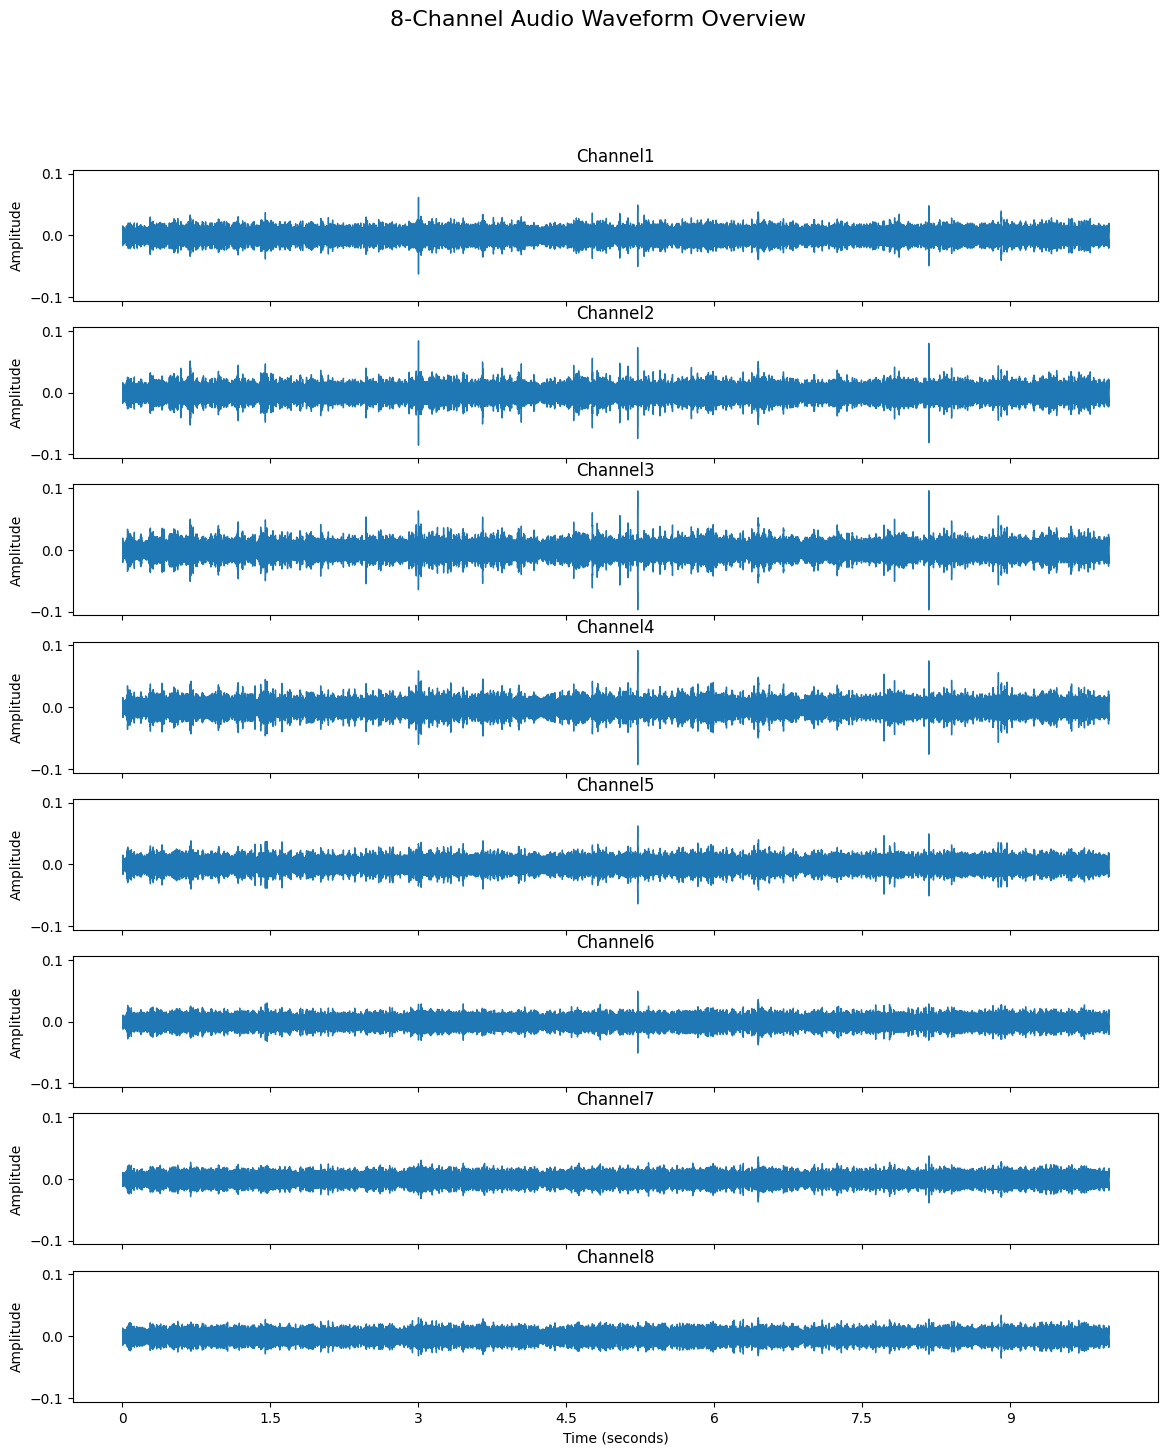

In [5]:
fig, axes = plt.subplots(nrows = 8, ncols = 1, figsize = (14, 16), sharex = True, sharey = True)
for i in range(8):
    librosa.display.waveshow(y[i], sr = sr, ax = axes[i])
    axes[i].set_title(f"Channel{i+1}")
    axes[i].set_ylabel("Amplitude")
    axes[i].label_outer() # hides reduntant internal tick labels to keep the plot clean

axes[-1].set_xlabel("Time (seconds)")
plt.suptitle("8-Channel Audio Waveform Overview", fontsize= 16)
plt.tight_layout
plt.show()

<b>Observation: </b>All 8 channels show the same temporal structure. The transient spikes occur at the same time instants across all channels (~3s, ~5s, ~7.5s).

In [7]:
# RMS Energy per channel
rms_per_channel = librosa.feature.rms(y =  y)
print(rms_per_channel.shape)
# Spectral Centroid per channel
centroid = librosa.feature.spectral_centroid(y = y)
print(centroid.shape)
# Cross- correlation Matrix between channels
cross_corr_matrix = np.corrcoef(y)
print(cross_corr_matrix.shape)

(8, 1, 313)
(8, 1, 313)
(8, 8)


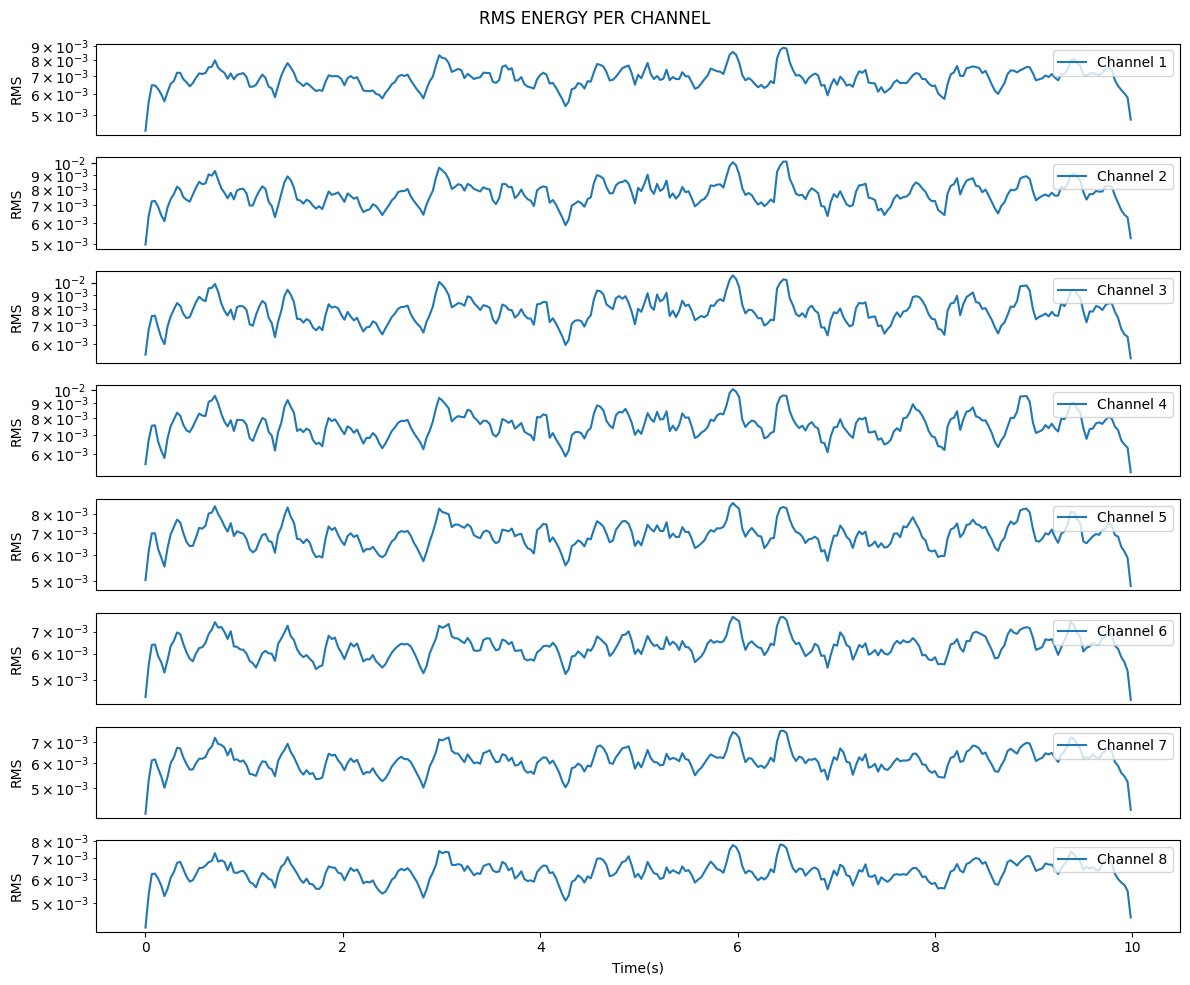

In [8]:
# Plotting RMS Energy per channel
times = librosa.times_like(rms_per_channel, sr = sr)
plt.figure(figsize = (12, 10))
for i in range(y.shape[0]):
    plt.subplot(y.shape[0], 1, i+1)
    plt.semilogy(times, rms_per_channel[i, 0], label=f"Channel {i+1}")
    plt.ylabel("RMS")
    plt.legend(loc="upper right")
    if i < y.shape[0] - 1:
        plt.xticks([])
    else:
        plt.xlabel("Time(s)")
plt.suptitle("RMS ENERGY PER CHANNEL")
plt.tight_layout()
plt.show()

<b>Observation: </b>All channels follow the exact same energy envelope over time - the peaks and valleys are synchronized. The absolute RMS values differ marginally: Channels 1-4 are at (~6-10X10^-3) while Channels 5-8 are at lower level (~5-8X10^-3). This is due to distance or directional effect from the circular array.

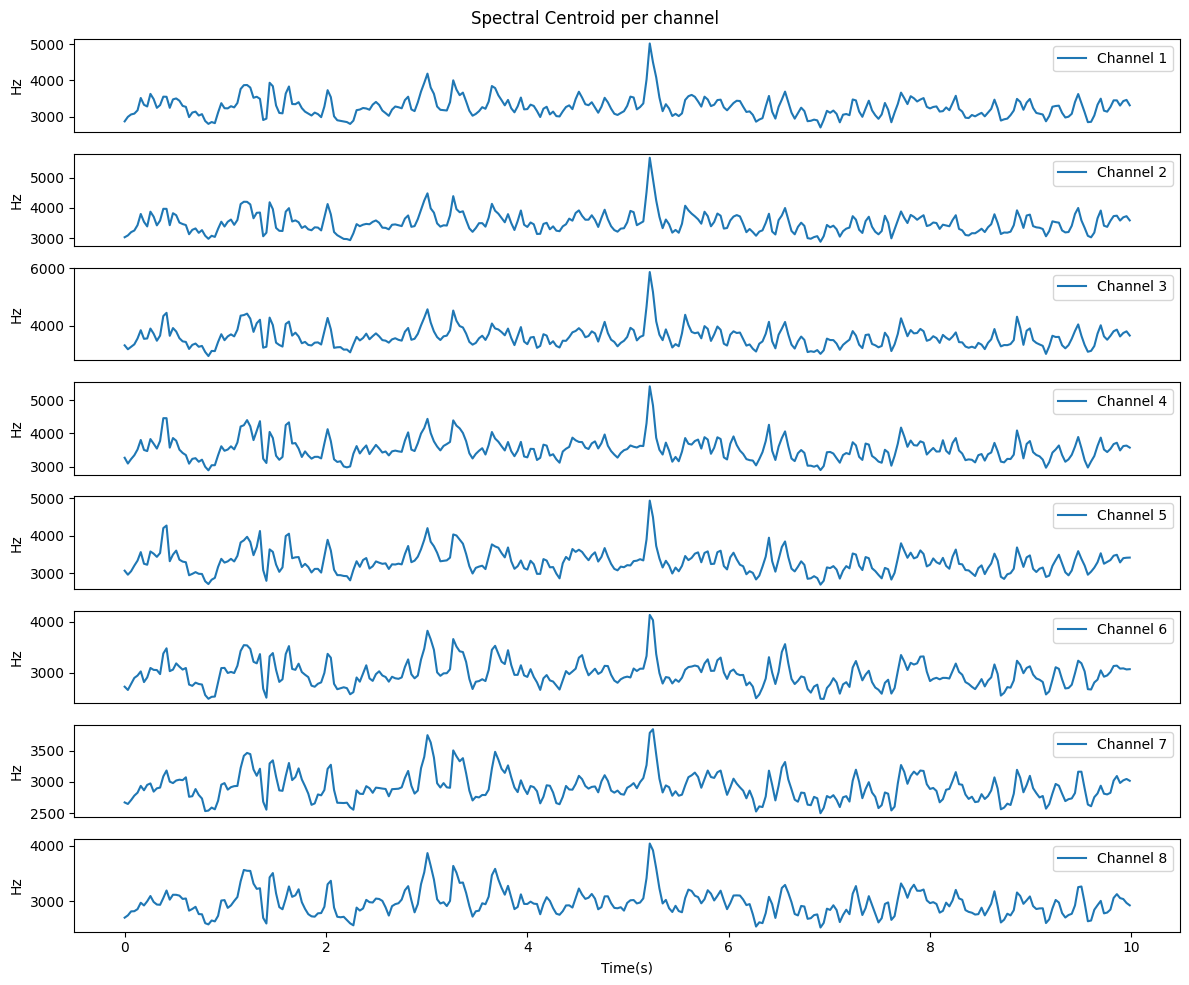

In [9]:
# Plotting Spectral Centroid per Channel
frames = range(centroid.shape[-1])
times = librosa.frames_to_time(frames, sr= sr)
plt.figure(figsize=(12, 10))
for i in range(y.shape[0]):
    plt.subplot(y.shape[0], 1, i+1)
    plt.plot(times, centroid[i, 0], label=f"Channel {i+1}")
    plt.ylabel("Hz")
    plt.legend(loc="upper right")
    if i < y.shape[0] - 1:
        plt.xticks([])
   
plt.xlabel('Time(s)')
plt.suptitle("Spectral Centroid per channel")
plt.tight_layout()
plt.show()

<b>Observation: </b>Channels 1-5 have centroids ranging from 3000 - 500 Hz, while Channels 6-8 have centroids ranging from 2500-4000 Hz. The temporal pattern, the spike at ~5s is preserved across all. The slight frequency rolloff in later channels suggests minor spatial coloration - but the same spectral content is captured everywhere.

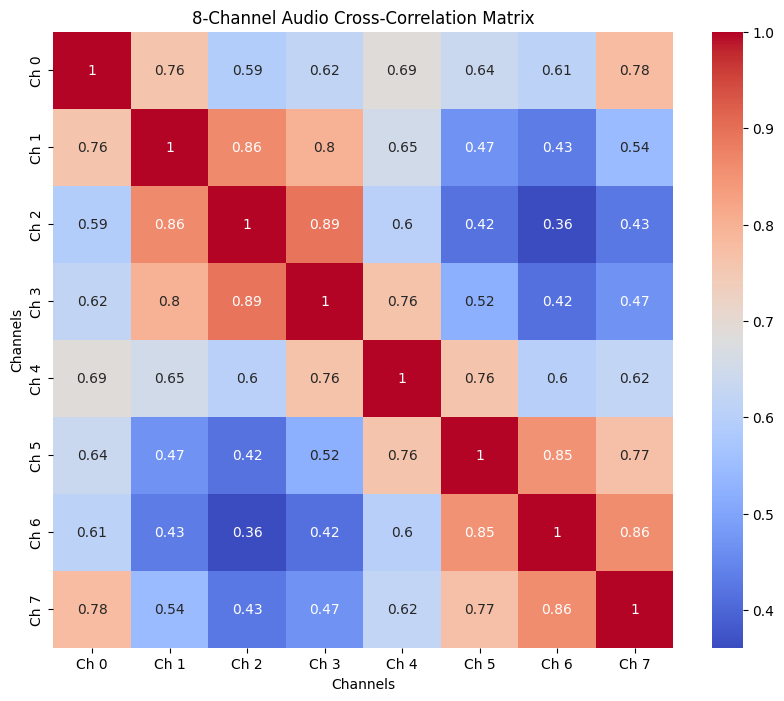

In [11]:
# Plotting Cross Correlation Coefficients between channels
plt.figure(figsize=(10, 8))
sns.heatmap(cross_corr_matrix, annot = True, cmap = 'coolwarm', xticklabels = [f'Ch {i}' for i in range(8)],
            yticklabels = [f'Ch {i}' for i in range(8)])
plt.title("8-Channel Audio Cross-Correlation Matrix")
plt.xlabel("Channels")
plt.ylabel("Channels")
plt.show()

<b>Observation:</b> 
- Adjacent microphones are highly correlated: Ch1↔Ch2 = 0.86, Ch2↔Ch3 = 0.89,  Ch5↔Ch6 = 0.85, Ch6↔Ch7 = 0.86.
- Opposite microphones are least correlated: Ch1↔Ch6 = 0.47, Ch2↔Ch6 = 0.36, Ch2↔Ch7 = 0.43 — this makes perfect sense as mics at 180° apart.
- Even the minimum correlation (0.36) is moderately high — confirming all channels carry essentially the same machine sound information.
- Ch 0 is well-correlated with everyone (0.59–0.78), making it a safe, balanced representative.

### <b>Channel Selection Decision: Use Channel 0</b>
- It has the highest minimum correlation with all other channels (0.59-0.78), making it the most central representative of the array.
- It has slightly higher RMS energy than Channels 5-8, suggeating better SNR relative to the noise floor.
- Its spectral centroid sits in the mid-range (not the highest, not the lowest), avoiding any directional bias.
- It is the conventional reference mic (#1 at 0°) as per the research paper of MIMII dataset.